In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

2025-08-30 04:44:57.499378: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-30 04:45:11.428552: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-30 04:45:25.611481: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
data = np.sin(np.linspace(0, 20, 100)).reshape(-1, 1)

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [4]:
# Create sequences for training
# We'll use a sequence of `look_back` values to predict the next value
look_back = 10  # Number of previous time steps to consider
X, y = [], []
for i in range(len(data_scaled) - look_back):
   X.append(data_scaled[i:(i + look_back), 0])
   y.append(data_scaled[i + look_back, 0])
X, y = np.array(X), np.array(y)

In [5]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
# 2. Build the LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1))) # 50 LSTM units
model.add(Dense(1)) # Output layer for predicting a single value
model.compile(optimizer='adam', loss='mse')

2025-08-30 04:46:51.334848: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# temporal split
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(patience=10, restore_best_weights=True)

model.fit(X_train, y_train, epochs=100, batch_size=16,
         validation_data=(X_val, y_val), callbacks=[es], shuffle=False)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.4110 - val_loss: 0.2334
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3477 - val_loss: 0.2067
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2908 - val_loss: 0.1808
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2329 - val_loss: 0.1548
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1770 - val_loss: 0.1316
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1288 - val_loss: 0.1133
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0973 - val_loss: 0.1039
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0875 - val_loss: 0.0991
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0847 - val_loss: 0.0943
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0799 - val_loss: 0.0903
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0762 - val_loss: 0.0874
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0733 - val_lo

In [8]:
last_sequence = data_scaled[-look_back:].reshape(1, look_back, 1)
pred_scaled = model.predict(last_sequence, verbose=0)
predicted_value = scaler.inverse_transform(pred_scaled)[0,0]

In [9]:
future_steps = 10
current = last_sequence.copy()
future_preds = []
for _ in range(future_steps):
   next_scaled = model.predict(current, verbose=0)
   future_preds.append(scaler.inverse_transform(next_scaled)[0,0])
   current = np.concatenate([current[:, 1:, :], next_scaled.reshape(1, 1, 1)], axis=1)


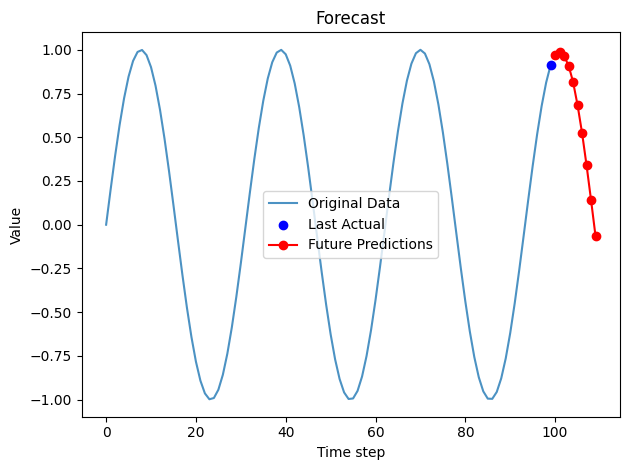

In [11]:
import matplotlib.pyplot as plt
last_idx = len(data) - 1
plt.plot(np.arange(len(data)), data, label='Original Data', alpha=0.8)
plt.scatter(last_idx, data[last_idx], color='blue', label='Last Actual', zorder=5)
future_x = np.arange(last_idx + 1, last_idx + 1 + len(future_preds))
plt.plot(future_x, future_preds, 'ro-', label='Future Predictions')
plt.legend(); plt.xlabel('Time step'); plt.ylabel('Value'); plt.title('Forecast')
plt.tight_layout(); plt.show()